In [1]:
import os
from scipy.io import loadmat
import numpy as np
# Ruta del archivo que se quiera cargar
home_dir = os.path.expanduser("~")
DataSimCianos = os.path.join(home_dir, "Desktop", "Spline Optimizer", "Saves", "simulationSol-E8.mat")

# Cargar el archivo MAT
data = loadmat(DataSimCianos)  # Aquí cargamos el archivo realmente

# Mostrar las claves (variables almacenadas en el archivo)
#print(data.keys())

# Acceder a una tabla específica por su clave (reemplaza 'nombre_tabla' por la clave real)
IDLogs = data["IDLog"] #Dimensiones: [instantes de tiempo x nº máx de partículas en algún instante] ej: [187x612]
#print("Tabla IDLogs: \n", IDLogs) 
parentCell = data["parentCell"] #Dimensiones: [1 x nº total de partículas que aparecen en la simulación] ej: [1x1261]
#print("Tabla parentCell: \n", parentCell)
tVec = data["tVec"] #Dimensiones [1 x instantes de tiempo] ej: [1x187]
#tVec está en dias, lo pasamos a minutos
tVec_min = tVec*24*60
#print("Tabla tVec", tVec)
xCellLog = data["xCellLog"] #Dimensiones [instantes de tiempo x nº máximo de partículas en algún instante x (x, y, z)] ej: [187x612x3]
#print("Tabla xCellLog: \n", xCellLog)


/tmp/ipykernel_3531/2776751106.py:160: RuntimeWarning: overflow encountered in exp
  pesos_gaussianos_repetidos = np.exp((-distancias_repetidas/rango_deteccion)**2 / (2 * alpha**2))


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      200 |      4 |             - |             -
     2 |      400 |      6 |  0.0353782698 |         nadir
     3 |      600 |      2 |  1.0000000000 |         ideal
     4 |      800 |      2 |  1.9595104026 |         nadir
     5 |     1000 |      5 |  0.9892702856 |         ideal
     6 |     1200 |      4 |  0.0311280204 |         ideal
     7 |     1400 |      6 |  0.0799730959 |         ideal
     8 |     1600 |      7 |  0.1006683433 |         ideal
     9 |     1800 |      7 |  0.4111384643 |         ideal
    10 |     2000 |      6 |  0.0948468186 |         ideal
    11 |     2200 |      6 |  0.3370107436 |         ideal
    12 |     2400 |      8 |  0.0054244979 |         ideal
    13 |     2600 |     10 |  0.0515329206 |         ideal
    14 |     2800 |     10 |  0.2707794355 |         ideal
    15 |     3000 |      7 |  0.1043600948 |         ideal
    16 |     3200 |     10 |  0.1436988545 |         ide

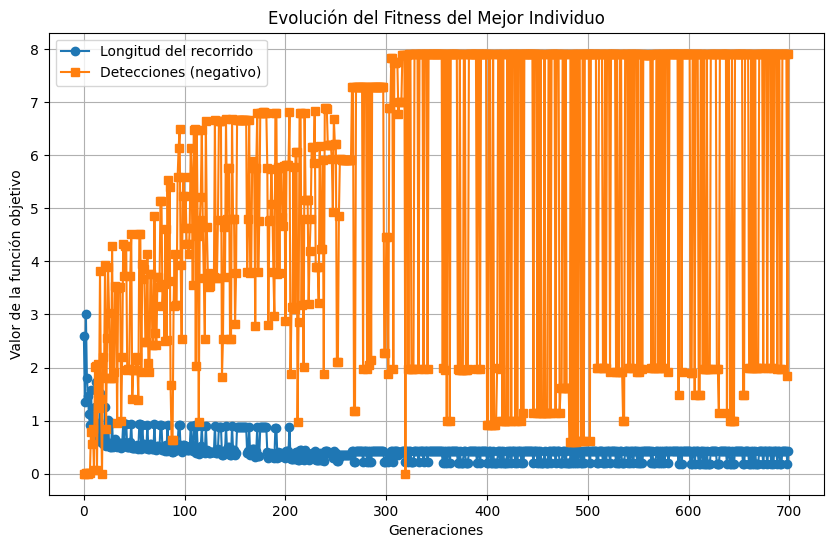

200


In [9]:
import matplotlib.pyplot as plt
import numpy as np
from pymoo.core.mutation import Mutation
from pymoo.core.crossover import Crossover
from pymoo.core.sampling import Sampling
from pymoo.core.problem import ElementwiseProblem
from pymoo.optimize import minimize
from pymoo.algorithms.moo.nsga2 import NSGA2

from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.termination.default import DefaultMultiObjectiveTermination

import csv

# # === Muestreo personalizado ===


class CustomSampling(Sampling):
    def __init__(self, punto_ini, punto_fin):
        super().__init__()
        self.punto_ini = punto_ini
        self.punto_fin = punto_fin

    def _do(self, problem, n_samples, **kwargs):
        samples = np.zeros((n_samples, problem.n_var))  # Matriz de muestras [Población x Variables]
        
        for i in range(n_samples):
            sample = []
            sample.extend(self.punto_ini)
            #print(self.punto_ini)
            for j in range(3, problem.n_var-3, 3):  # Iterar en pasos de 3 (x, y, z)
                    x = np.random.uniform(problem.xl[j], problem.xu[j])   # Generar X dentro del rango
                    y = np.random.uniform(problem.xl[j+1], problem.xu[j+1]) # Generar Y dentro del rango
                    z = np.random.uniform(problem.xl[j+2], problem.xu[j+2]) # Generar Z dentro del rango
                    nueva_pos = [x, y, z]
                    #print(f"nueva_pos = {nueva_pos}")
                    # Comprobar la distancia mínima entre la nueva partícula y las anteriores
                    sample.extend(nueva_pos)       
            sample.extend(self.punto_fin)
            samples[i] = sample  # Guardar el individuo generado
            np.savetxt("sample.txt", samples)
        return samples

 # === Cruce personalizado ===
class CustomCrossover(Crossover):
    def __init__(self):
        super().__init__(2, 2)  # 2 padres -> 2 hijos
    
    def _do(self, problem, X, **kwargs):

        _, n_matings, n_var = X.shape  # Dimensiones de los padres
        
        # Crear la matriz de hijos con la misma estructura que X
        Y = np.full_like(X, np.nan)  
        
        for i in range(n_matings):  
            
            parent1, parent2 = X[0, i].copy(), X[1, i].copy()  # Copias de los padres            
            child1, child2 = np.copy(parent1), np.copy(parent2)  # Inicializar hijos
            
            for j in range(3, n_var-6, 3):  # Intercambio en bloques de 3
                if j + 3 <= n_var and np.random.rand() < 0.5:
                   
                    temp = np.copy(child1[j:j+3])
                    child1[j:j+3] = child2[j:j+3]
                    child2[j:j+3] = temp 
            Y[0, i] = child1
            Y[1, i] = child2

        # with open("crossover_output.txt", "w") as f:
        #     #print("Generando crossover_output.txt...")
        #     f.write("Padre 1".ljust(15) + "Padre 2".ljust(15) + "Hijo 1".ljust(15) + "Hijo 2".ljust(15) + "\n")
        #     f.write("=" * 60 + "\n")
        
        #     for i in range(n_matings):
        #         for j in range(n_var):
        #             f.write(f"{X[0, i, j]:<14.4f} {X[1, i, j]:<14.4f} {Y[0, i, j]:<14.4f} {Y[1, i, j]:<14.4f} \n")
        #         f.write("-" * 60 + "\n")
                
        return Y  # ¡IMPORTANTE! Siempre devolver `Y`




# === Mutación personalizada ===
class CustomMutation(Mutation):
    def __init__(self, sigma=0.2, prob=0.2, lower=None, upper=None):
        """
        sigma: desviación estándar de la mutación (cuánto se altera cada coordenada).
        prob: probabilidad de mutar cada coordenada.
        lower: lista de arrays de límites inferiores para cada coordenada (por ejemplo, [[x_lower], [y_lower], [z_lower]]).
        upper: lista de arrays de límites superiores para cada coordenada (por ejemplo, [[x_upper], [y_upper], [z_upper]]).
        """
        super().__init__()
        self.sigma = sigma
        self.prob = prob
        self.lower = lower
        self.upper = upper

    def _do(self, problem, X, **kwargs):
        n_ind, n_var = X.shape  # Cantidad de individuos y variables

        # Creamos una copia de los individuos
        mutated_X = np.copy(X)

        # Aplicamos mutación con probabilidad `self.prob`
        mask = np.random.rand(n_ind, n_var) < self.prob
        mask[:, :3] = False
        mask[:, -3:] = False
        noise = np.random.randn(n_ind, n_var) * problema.rango_deteccion  # Ruido gaussiano
        mutated_X[mask] += noise[mask]  
        #print(f"Individuo {X}")
        # Controlar que las variables no se excedan de los límites por coordenada
        if self.lower is not None and self.upper is not None:
            for i in range(3, n_var-3, 1):
                # Si hay un límite específico para la coordenada i, aplicarlo
                mutated_X[:, i] = np.clip(mutated_X[:, i], self.lower[i], self.upper[i])
        #         print(f"Mutado {mutated_X}")
        
        # with open("mutacion_output.txt", "w") as f:
        #     f.write("Individuo | Variable | Mascara | Original | Mutado | Noise | Lower | Upper\n")
        #     f.write("-" * 50 + "\n")

        #     for i in range(n_ind):
        #         for j in range(n_var):
        #             f.write(f"{i+1:<9} | {j+1:<8} | {int(mask[i, j]):<7} | {X[i, j]:<8.4f} | {mutated_X[i, j]:<8.4f} | {noise[i,j]:<8.4f} | {self.lower[j]:<8.4f} | {self.upper[j]:<8.4f}\n")
        #         f.write("\n")  # Separación entre individuos
                
        return mutated_X


# === Función para calcular la distancia Euclidiana en 3D ===
def calcular_distancia(p1, p2):
    return np.sqrt((p1[0]-p2[0])**2+(p1[1]-p2[1])**2)

def eliminar_particulas_en_rango(mapa, centro, rango_deteccion, indices_detectados, deteccion):
    # Definir sigma basado en el radio de detección
    aportaciones = np.zeros(len(indices_detectados))
    sigma = 0.1
    alpha = 0.2 #Para que las repetidas solo tengan influencia si se pasa muy cerca
    centro = np.array(centro[:2])
    epsilon = np.exp(-4.5**2/sigma**2)
    
    # Filtrar partículas que no han sido detectadas y no tienen NaN
    mascara_validas = (indices_detectados == 0)
    mascara_detectadas = (indices_detectados == 1)

    # Calcular distancias para partículas válidas y detectadas previamente
    distancias = np.linalg.norm(mapa[mascara_validas, :2] - centro, axis=1)
    distancias_repetidas = np.linalg.norm(mapa[mascara_detectadas, :2] - centro, axis=1)

    # Crear máscaras para evitar NaN en cálculos
    mascara_no_nan = ~np.isnan(distancias)
    mascara_no_nan_repetidas = ~np.isnan(distancias_repetidas)
    
    # Aplicar la función gaussiana a partículas dentro del radio
    pesos_gaussianos = np.exp(-(distancias/rango_deteccion)**2 / (2 * sigma**2))      
    pesos_gaussianos_repetidos = np.exp((-distancias_repetidas/rango_deteccion)**2 / (2 * alpha**2))
    
    # Sumar la contribución de las partículas dentro del radio   
    repetidas = np.sum(pesos_gaussianos_repetidos[(~np.isnan(distancias_repetidas)) & (distancias_repetidas <= rango_deteccion)])
    #deteccion = np.sum(pesos_gaussianos[(~np.isnan(distancias)) & (distancias <= rango_deteccion)]-repetidas)
    
    # Marcar las partículas detectadas en indices_detectados
    #indices_detectados[mascara_validas] = ((distancias <= rango_deteccion) & (pesos_gaussianos >= epsilon)).astype(int)
    indices_detectados[mascara_validas] = (distancias <= rango_deteccion).astype(int)
    aportaciones[mascara_validas] = pesos_gaussianos
    deteccion = np.sum(indices_detectados)
    #print(f"Aportaciones = {aportaciones}, suma = {np.sum(aportaciones)}")
    
    return indices_detectados, repetidas, deteccion, aportaciones



# === Problema de optimización ===
class OptimizacionConDeteccion(ElementwiseProblem):
    def __init__(self, mapa_particulas, n_puntos=10, rango_deteccion=2, max_dist=1000, v_media=1):
        self.mapa_particulas = mapa_particulas  # Partículas en 3D
        self.rango_deteccion = rango_deteccion
        self.n_puntos = n_puntos
        self.max_dist = max_dist
        self.v_media = v_media*60 #Lo paso a m/min para que esté acorde con el vector de tiempos
        self.xl = np.array([-600, -400, -20])
        self.xu = np.array([600, 200, 0])
        self.mejor_fitness = float('inf')  # Inicializa como un valor muy alto
        self.mejor_deteccion = 0
        self.mapa_dinamico_mejor = None  # Para guardar el mejor mapa dinámico
        self.mejor_individuo = None
        self.long_max = calcular_distancia(self.xl[:2], self.xu[:2]) #Calculamos la longitud máxima para normalizar las longitudes
        # Definir el número de variables como el número de puntos de paso (n_puntos * 3 coordenadas)
        super().__init__(n_var=n_puntos*3, 
                         n_obj=2, 
                         n_constr=0, 
                         xl=np.tile(self.xl, n_puntos), 
                         xu=np.tile(self.xu, n_puntos))

    def _evaluate(self, x, out, *args, **kwargs):
        # x contiene los índices de las partículas ordenadas para el recorrido
        recorrido = [x[i:i+3] for i in range(0, len(x), 3)]

        # Longitud total del recorrido
        longitud_recorrido = 0
        penalty = 0
        mov=0
        longitudes=[]
        detecciones_totales = 0
        detecciones_totales = [np.zeros(len(self.mapa_particulas[1]))]
        repetidas_totales = 0
        repetidas_totales = 0
        tiempo=tVec_min[0,0] #Tomamos como orgien el tiempo inicial de la simulación
        indices_detectados = np.zeros(len(self.mapa_particulas[1]))
        pesos_gaussianos_i =  np.zeros(len(self.mapa_particulas[1]))
        aportaciones = np.zeros(len(self.mapa_particulas[1]))
        indices_repetidas = np.zeros(len(self.mapa_particulas[1])) 
        
        # Iterar sobre el recorrido y calcular la longitud total
        for i in range(len(recorrido)):
            deteccion = 0
            p1 = recorrido[i]
            if (i < len(recorrido)-1):
                p2 = recorrido[i + 1]
                longitud_recorrido += calcular_distancia(p1, p2)

            tAct = tiempo + longitud_recorrido/(self.v_media*60)
            dif_tVec_tAct = np.abs(tVec_min - tAct) #Hacemos el absoluto para buscar el 0, es decir, el más cercano al instante actual
            indice_tVec = np.argmin(dif_tVec_tAct) #El índice que tengo que buscar en 
            
            #print(f"tAct: {tAct}, tVec: {tVec_min}")
            #print(f"Diferencia absoluta: {dif_tVec_tAct}")
            #print(f"Índice del valor más cercano: {indice_tVec}")
            
            # Actualizar el mapa y contar las partículas detectadas
            indices_detectados, detecciones, repetidas, aportaciones = eliminar_particulas_en_rango(xCellLog[indice_tVec, :, :], p1, self.rango_deteccion, indices_detectados, deteccion)

            mask_aportaciones = pesos_gaussianos_i < aportaciones
            pesos_gaussianos_i[mask_aportaciones] = aportaciones[mask_aportaciones]
            #detecciones_totales += detecciones #En este caso, la funcion eliminar_particulas_en_rango ya aplica castigo por detectar varias veces la misma partícula
            
            repetidas_totales += repetidas
            
            if (i < len(recorrido)-1):
                mov += calcular_distancia(p1, p2)
                if mov <= self.rango_deteccion or mov > self.max_dist:
                    penalty += 1/self.n_puntos
                else:
                    penalty += 0
                    
        detecciones_totales = np.nansum(pesos_gaussianos_i)

        # Definir la función objetivo: minimizar la longitud y maximizar las detecciones
        out["F"] = [longitud_recorrido/self.long_max, -detecciones_totales]  # Usamos -detecciones_totales para maximizar. Normalizamos las detecciones con el n máx de partículas y la longitud con la longitud máxima de la población
        #out["G"] = [g]

convergence = []

def callback(algorithm):
    gen = algorithm.n_gen
    pop = algorithm.pop
    F = pop.get("F")  # Obtener valores de función objetivo de la población
    
    # Obtener el mejor (mínimo) valor de cada función objetivo
    best_fitness_detecc_ind = np.argmin(F[1])
    best_fitness = F[best_fitness_detecc_ind] 
    
    # Guardar el mejor fitness de cada generación
    convergence.append(best_fitness)

# Crear el problema de optimización
problema = OptimizacionConDeteccion(xCellLog)

# Crear el algoritmo NSGA-II
algorithm = NSGA2(
    pop_size=200,
    #n_offsprings=10,
    crossover=CustomCrossover(),
    mutation=CustomMutation(lower = problema.xl, upper = problema.xu),
    sampling=CustomSampling(punto_ini =[0, 0, 0], punto_fin = [0, 0, 0]),
    #mutation=PM(prob=0.2, eta=10),
    eliminate_duplicates=True
)

algorithm.callback = callback

termination = DefaultMultiObjectiveTermination(
    xtol=1e-8,
    cvtol=1e-6,
    ftol=0.0025,
    period=30,
    n_max_gen=700,
    n_max_evals=1000000
)

# Ejecutar la optimización
result = minimize(
    problema,
    algorithm,
    termination,
    seed=42,
    verbose=True,
    save_history=True
)

n_evals = np.array([e.evaluator.n_eval for e in result.history])
opt = np.array([e.opt[0].F for e in result.history])

#Buscamos el result.X que tenga un mayor número de detecciones
ind_mejor_individuo = np.argmin(result.F[1])
mejor_individuo = result.X[ind_mejor_individuo]
    
# Convertir la lista a un array para facilitar la manipulación
convergence = np.array(convergence)

# Crear la gráfica
plt.figure(figsize=(10, 6))

plt.plot(convergence[:, 0], label="Longitud del recorrido", marker="o")
plt.plot(-convergence[:, 1], label="Detecciones (negativo)", marker="s")

plt.xlabel("Generaciones")
plt.ylabel("Valor de la función objetivo")
plt.title("Evolución del Fitness del Mejor Individuo")
plt.legend()
plt.grid()
plt.show()

print(len(result.F))

In [ ]:
#Ahora saco la evolución de las detecciones al igual que en la evaluacion para sacar las partículas que se han ido detectando en cada t
# Iterar sobre el recorrido y calcular la longitud total
recorrido = [mejor_individuo[i:i+3] for i in range(0, len(mejor_individuo), 3)]

tiempo=tVec_min[0,0] #Tomamos como orgien el tiempo inicial de la simulación
indices_detectados = np.zeros(len(problema.mapa_particulas[1]))
pesos_gaussianos_i =  np.zeros(len(problema.mapa_particulas[1]))
aportaciones = np.zeros(len(problema.mapa_particulas[1]))
indices_repetidas = np.zeros(len(problema.mapa_particulas[1])) 
longitud_recorrido = 0
mapa_dinamico_detecciones = np.zeros((len(recorrido), len(indices_detectados)))
for i in range(len(recorrido)):
    deteccion = 0
    p1 = recorrido[i]
    if (i < len(recorrido)-1):
        p2 = recorrido[i + 1]
        longitud_recorrido += calcular_distancia(p1, p2)
    #print(f"p{i} = {p1}")
    tAct = tiempo + longitud_recorrido/(problema.v_media*60)
    dif_tVec_tAct = np.abs(tVec_min - tAct) #Hacemos el absoluto para buscar el 0, es decir, el más cercano al instante actual
    indice_tVec = np.argmin(dif_tVec_tAct) #El índice que tengo que buscar en 
    #print(f"tAct: {tAct}, tVec: {tVec_min}")
    #print(f"Diferencia absoluta: {dif_tVec_tAct}")
    #print(f"Índice del valor más cercano: {indice_tVec}")
    
    # Actualizar el mapa y contar las partículas detectadas
    indices_detectados, detecciones, repetidas, aportaciones = eliminar_particulas_en_rango(xCellLog[indice_tVec, :, :], p1, problema.rango_deteccion, indices_detectados, deteccion)
    mapa_dinamico_detecciones[i] = indices_detectados


In [15]:
result.X.shape

(200, 30)

In [16]:
result.F.shape

(200, 2)

In [38]:
result.F[ind_mejor_individuo,1]

-7.910061988211808

In [1]:
import numpy as np
import matplotlib.pyplot as plt

ind_mejor_individuo = np.argmin(result.F[:,1])
mejor_individuo = result.X[ind_mejor_individuo]
mapa_mejor = mapa_dinamico_detecciones

tiempos_ruta = np.zeros(int(len(mejor_individuo) / 3))
x = []
y = []
z = []
j = 0
v_media = 1

plt.ion()  # Activar modo interactivo
zeros = []

for i in range(len(tiempos_ruta)):
    p1 = [mejor_individuo[i], mejor_individuo[i+1], mejor_individuo[i+2]]
    p2 = [mejor_individuo[i+3], mejor_individuo[i+4], mejor_individuo[i+5]]
    zeros.append(0)
    
    # Cálculo de tiempos de la ruta
    if i == 0:
        tiempos_ruta[i] = tVec_min[0, 0]
    else:
        tiempos_ruta[i] = tiempos_ruta[i - 1] + calcular_distancia(p1, p2) / (v_media * 60)  # v_media en m/min
    
    dif_tVec_tAct = np.abs(tVec_min - tiempos_ruta[i])
    indice_tVec = np.argmin(dif_tVec_tAct)
    print(f"Tiempo de la ruta (s): {(tiempos_ruta[i]-tiempos_ruta[0])*60}")

    # Obtener las coordenadas de las partículas
    map_x = xCellLog[indice_tVec, :, 0]
    map_y = xCellLog[indice_tVec, :, 1]
    map_z = xCellLog[indice_tVec, :, 2]

    indices_detectados_i = mapa_mejor[i]
    colores = ["yellow" if indices_detectados_i[k] == 1 else 'green' for k in range(len(indices_detectados_i))]
    print(f"INDICES DETECTADOS = {np.sum(indices_detectados_i)}")
    # Agregar el punto actual antes de graficar
    x.append(mejor_individuo[j])
    y.append(mejor_individuo[j+1])
    z.append(mejor_individuo[j+2])

    # Crear figura con 4 subgráficos
    fig = plt.figure(figsize=(12, 10))

    # 3D View
    ax1 = fig.add_subplot(221, projection='3d')
    ax1.scatter(map_x, map_y, map_z, c=colores, marker='o', alpha=1)
    ax1.scatter(x, y, z, c='b', marker='o')  # Puntos en 3D
    ax1.scatter(x, y, zeros, c='r', marker='o')  # Puntos proyectados en rojo (Z=0)

    # Líneas rojas entre los puntos proyectados en el suelo (Z=0)
    ax1.plot(x, y, zeros, c='r', linestyle='-', linewidth=2)

    # Líneas azules entre cada punto rojo (proyección) y su correspondiente punto azul en 3D
    for k in range(len(x)):
        ax1.plot([x[k], x[k]], [y[k], y[k]], [0, z[k]], c='b', linestyle='-', linewidth=2)

    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.set_title("Vista 3D")

    # Vista desde X (YZ-plane)
    ax2 = fig.add_subplot(222)
    ax2.scatter(map_y, map_z, c=colores, marker='o', alpha=1)
    ax2.scatter(y, z, c='b', marker='o')
    ax2.scatter(y, zeros, c='red', marker='o')

    # Líneas rojas en el suelo (YZ)
    ax2.plot(y, zeros, c='r', linestyle='-', linewidth=2)

    # Líneas azules de proyección de cada punto
    for k in range(len(y)):
        ax2.plot([y[k], y[k]], [0, z[k]], c='b', linestyle='-', linewidth=2)

    ax2.set_xlabel('Y')
    ax2.set_ylabel('Z')
    ax2.set_title("Vista desde X (YZ-plane)")

    # Vista desde Y (XZ-plane)
    ax3 = fig.add_subplot(223)
    ax3.scatter(map_x, map_z, c=colores, marker='o', alpha=1)
    ax3.scatter(x, z, c='b', marker='o')
    ax3.scatter(x, zeros, c='red', marker='o')

    # Líneas rojas en el suelo (XZ)
    ax3.plot(x, zeros, c='r', linestyle='-', linewidth=2)

    # Líneas azules de proyección de cada punto
    for k in range(len(x)):
        ax3.plot([x[k], x[k]], [0, z[k]], c='b', linestyle='-', linewidth=2)

    ax3.set_xlabel('X')
    ax3.set_ylabel('Z')
    ax3.set_title("Vista desde Y (XZ-plane)")

    # Vista desde Z (XY-plane)
    ax4 = fig.add_subplot(224)
    ax4.scatter(map_x, map_y, c=colores, marker='o', alpha=1)
    ax4.scatter(x, y, c='b', marker='o')
    ax4.scatter(x, y, c='red', marker='o', alpha = 0.2)

    # Línea roja conectando los puntos XY
    ax4.plot(x, y, c='r', linestyle='-', linewidth=2)

    # Dibujar un círculo en el punto actual
    radio = 2  # Define el radio del círculo según lo necesites
    circle = plt.Circle((x[-1], y[-1]), radio, color='r', fill=False, linewidth=2)
    ax4.add_patch(circle)  # Agregar el círculo al gráfico
    for idx, (xi, yi, zi) in enumerate(zip(x, y, z)):
        ax4.text(xi, yi, str(idx+1), color='blue', fontsize=12, fontweight='bold')  # Vista XY
    ax4.set_xlabel('X')
    ax4.set_ylabel('Y')
    ax4.set_title("Vista desde Z (XY-plane) - Ruta en rojo")
    if(i < len(tiempos_ruta)-1 ):
        ax4.set_xlim(min(x[-1] - 100, min(x)), max(x[-1] + 100, max(x)))
        ax4.set_ylim(min(y[-1] - 100, min(y)), max(y[-1] + 100, max(y)))
    else:
        ax4.set_xlim(min(x[0] - 300, min(x)), max(x[0] + 300, max(x)))
        ax4.set_ylim(min(y[0] - 300, min(y)), max(y[0] + 300, max(y)))

    # Añadir etiquetas numeradas para cada punto visitado

    plt.show()
    plt.pause(0.1)  # Pequeña pausa para visualizar correctamente
    
    j += 3

tiempos_ruta  # Esta línea muestra los tiempos de la ruta


NameError: name 'result' is not defined

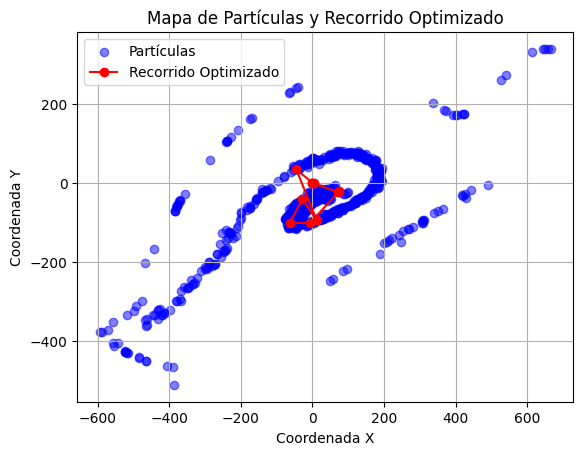

In [6]:
import matplotlib.pyplot as plt

# Suponiendo que el mejor resultado de la optimización se guarda en 'mejor_individuo'
# y que las partículas están almacenadas en 'mapa_particulas'
# Vamos a visualizar las partículas y la trayectoria resultante

def plot_resultados(mapa_particulas, mejor_individuo):
    # Extraer las coordenadas de las partículas
    particulas_x = mapa_particulas[:, 0]  # X de las partículas
    particulas_y = mapa_particulas[:, 1]  # Y de las partículas

    # Traza de las partículas en el mapa
    plt.scatter(particulas_x, particulas_y, c='blue', label='Partículas', alpha=0.5)

    # Traza de la trayectoria del mejor resultado
    # Extraer la trayectoria del mejor individuo (asumimos que 'mejor_individuo' tiene las coordenadas en bloques de 3)
    trayectoria_x = [mejor_individuo[i] for i in range(0, len(mejor_individuo), 3)]
    trayectoria_y = [mejor_individuo[i+1] for i in range(0, len(mejor_individuo), 3)]
    
    # Conectar los puntos con líneas
    plt.plot(trayectoria_x, trayectoria_y, c='red', marker='o', label='Recorrido Optimizado')

    # Personalización del gráfico
    plt.title("Mapa de Partículas y Recorrido Optimizado")
    plt.xlabel("Coordenada X")
    plt.ylabel("Coordenada Y")
    plt.legend()
    plt.grid(True)
    
    # Mostrar la gráfica
    plt.show()

# Ejemplo de uso:
# Asumimos que `mapa_particulas` es una matriz con las coordenadas [x, y, z] de las partículas
# Y `mejor_individuo` es el mejor resultado de la optimización, con las coordenadas de los puntos de paso
mejor_individuo = result.X[0]
plot_resultados(xCellLog[0,:,:], mejor_individuo)
